# Waveform Feature Extraction — Test Notebook

Extracts and visualises mean multi-channel spike waveforms from a single
Neuropixels session.  
Edit **Section 0** (the config cell) and run all cells.

**Outputs**
- Per-unit waveform grid (8 channels, probe-geometry layout)
- Mean ± SD waveform per cell type
- Waveform scalar features table (trough-to-peak, half-width, amplitude)
- Saved `.npz` feature file

## 0 · Configuration
Edit the cells below — everything else runs without changes.

In [35]:
import sys, pathlib

# ── Path to the cerebellum_cell_classifier package ──────────────────────────
PROJECT_ROOT = pathlib.Path(r"C:\Users\lidor\cerebellum_cell_classifier")
if str(PROJECT_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.parent))

# ── Session folder (Kilosort output + .ap.bin) ───────────────────────────────
SESSION_PATH = pathlib.Path(r"E:\data\AA23\AA23_05")

# ── Binary file ──────────────────────────────────────────────────────────────
# Set explicitly when there are multiple .ap.bin files in the session folder.
# Set to None to auto-detect (only works when there is exactly one .ap.bin).
BIN_PATH = (r"E:\data\AA23\AA23_05\original_data\AA23_05_g0_tcat.imec0.ap.bin")
# BIN_PATH = SESSION_PATH / "my_recording_g0_t0.imec0.ap.bin"

# ── Expert cell-type labels ──────────────────────────────────────────────────
# {cluster_id (int): label (str)}
# Supported: 'PC', 'CF', 'MLI', 'GC', 'UBC', 'MF', 'unknown'
#
# UNIT SELECTION RULES (applied in order):
#   1. UNIT_IDS is set          → process exactly those IDs
#   2. CELL_TYPE_LABELS is set  → process only the keys of this dict
#   3. Both empty               → process all good units from cluster_info.tsv
CELL_TYPE_LABELS = {
     5:   "PC",
     124: "PC",
     340: "PC",
}

# ── Explicit unit list (overrides CELL_TYPE_LABELS keys) ────────────────────
# Set to None to let CELL_TYPE_LABELS (or all good units) decide.
UNIT_IDS = None     # e.g. [5, 124, 340]

# ── Probe / extraction settings ─────────────────────────────────────────────
N_CH_TOTAL   = 385      # 385 for NP1 & NP2 (384 neural + 1 sync)
                        # Use 384 only if your .ap.bin has no sync channel
N_CH_EXTRACT = 8        # channels extracted per unit
MAX_SPIKES   = 3_000    # spike count cap per unit
DO_REALIGN   = True     # align each spike to its local peak

# ── Output ───────────────────────────────────────────────────────────────────
SAVE_PATH = PROJECT_ROOT / "notebooks" / "waveform_features.npz"

print("Config OK")

Config OK


In [36]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.facecolor" : "#0d0d1a",
    "axes.facecolor"   : "#0d0d1a",
    "axes.edgecolor"   : "#444",
    "axes.labelcolor"  : "#ccc",
    "xtick.color"      : "#ccc",
    "ytick.color"      : "#ccc",
    "text.color"       : "#eee",
    "figure.dpi"       : 120,
})

CT_COLORS = {
    "PC"      : "#4C8EFF",
    "CF"      : "#FF6B35",
    "MLI"     : "#55C96A",
    "GC"      : "#E040FB",
    "UBC"     : "#FFD740",
    "MF"      : "#26C6DA",
    "unknown" : "#888888",
}

print("Imports OK")

Imports OK


## 1 · Load Kilosort data

In [37]:
from cerebellum_cell_classifier.io.kilosort import load_kilosort

ks = load_kilosort(SESSION_PATH)

print(f"Session   : {SESSION_PATH.name}")
print(f"Spikes    : {len(ks.spike_times):,}")
print(f"Good units: {len(ks.good_units)}")
print(f"Channels  : {len(ks.channel_map)}  "
      f"(y range {ks.channel_positions[:,1].min():.0f}–"
      f"{ks.channel_positions[:,1].max():.0f} µm)")

# Show all .ap.bin files so you can pick the right one for BIN_PATH
bin_files = sorted(SESSION_PATH.glob("*ap.bin"))
print(f"\n.ap.bin files found ({len(bin_files)}):")
for f in bin_files:
    size_gb = f.stat().st_size / 1e9
    print(f"  {f.name}  ({size_gb:.2f} GB)")
if len(bin_files) > 1:
    print("  ⚠  Multiple files — set BIN_PATH explicitly in the config cell!")

Session   : AA23_05
Spikes    : 10,889,832
Good units: 148
Channels  : 384  (y range 600–3465 µm)

.ap.bin files found (1):
  AA23_05_g0_tcat.imec0_tempfiltNone300TrueFalse.ap.bin  (44.98 GB)


## 2 · Extract mean waveforms

In [ ]:
from cerebellum_cell_classifier.features.waveform import (
    build_waveform_features,
    normalize_waveforms,
)

# ── Resolve which units to process ──────────────────────────────────────────
if UNIT_IDS is not None:
    unit_ids = np.asarray(UNIT_IDS, dtype=np.int64)
    print(f"Using UNIT_IDS: {len(unit_ids)} units")
elif CELL_TYPE_LABELS:
    unit_ids = np.asarray(sorted(CELL_TYPE_LABELS.keys()), dtype=np.int64)
    print(f"Using CELL_TYPE_LABELS keys: {len(unit_ids)} units → {unit_ids.tolist()}")
else:
    unit_ids = ks.good_units
    print(f"Using all good units: {len(unit_ids)} units")

# ── Extract ──────────────────────────────────────────────────────────────────
result = build_waveform_features(
    session_path         = SESSION_PATH,
    ks_data              = ks,
    unit_ids             = unit_ids,
    cell_type_labels     = CELL_TYPE_LABELS,
    bin_path             = BIN_PATH,
    n_channels_total     = N_CH_TOTAL,
    n_channels_extract   = N_CH_EXTRACT,
    max_spikes           = MAX_SPIKES,
    do_realign           = DO_REALIGN,
    use_template_channel = True,
    verbose              = True,
)

result["norm_waveforms"] = normalize_waveforms(result["mean_waveforms"])

print(f"\nmean_waveforms : {result['mean_waveforms'].shape}")
print(f"n_spikes       : {result['n_spikes']}")
print(f"Labels         : {dict(zip(*np.unique(result['cell_type_labels'], return_counts=True)))}")

## 3 · Quick sanity check — verify data before plotting

unit_ids : [  5 124 340]
labels   : ['PC' 'PC' 'PC']

  unit    5 [PC]  amplitude = 94.78 µV  min=-158.02  max=-63.24
  unit  124 [PC]  amplitude = 158.41 µV  min=-162.11  max=-3.70
  unit  340 [PC]  amplitude = 195.75 µV  min=-314.41  max=-118.66


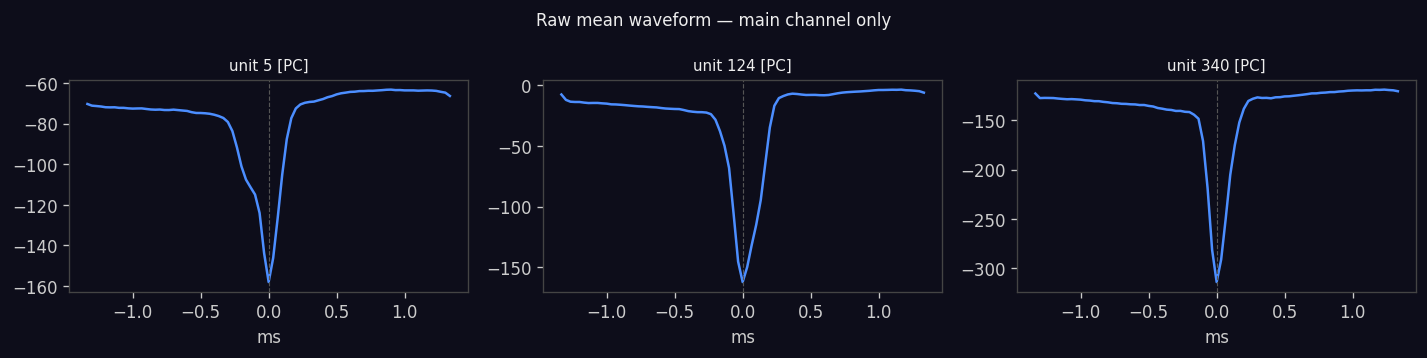

In [39]:
print("unit_ids :", result["unit_ids"])
print("labels   :", result["cell_type_labels"])
print()

t_ms = (np.arange(81) - 40) / 30.0
n_units = len(result["unit_ids"])

fig, axes = plt.subplots(1, n_units, figsize=(4 * n_units, 3), squeeze=False)

for i in range(n_units):
    ax    = axes[0, i]
    uid   = result["unit_ids"][i]
    label = result["cell_type_labels"][i]
    wf    = result["mean_waveforms"][i, 0, :]   # raw main channel
    amp   = wf.max() - wf.min()
    print(f"  unit {uid:4d} [{label}]  amplitude = {amp:.2f} µV  "
          f"min={wf.min():.2f}  max={wf.max():.2f}")

    ax.plot(t_ms, wf, color=CT_COLORS.get(label, "#888"), lw=1.5)
    ax.axvline(0, color="#555", lw=0.7, ls="--")
    ax.set_title(f"unit {uid} [{label}]", fontsize=9)
    ax.set_xlabel("ms")

plt.suptitle("Raw mean waveform — main channel only", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:

# ── 3-step pipeline comparison — main channel only ───────────────────────────
# Extracts spikes for the first unit and compares mean WF at each stage:
#   1. Raw        — int16 from binary, no processing
#   2. Detrended  — scipy linear detrend per spike  (= mydetrend)
#   3. Realigned  — peak-aligned with np.roll       (= realign_spikes.m)

from scipy.signal import detrend as scipy_detrend

N_SAMPLES   = 81
PEAK_SAMPLE = 40
MAX_SHIFT   = 12
N_SPIKES_DBG = 500   # spikes to use for this check

# ── Pick first unit ──────────────────────────────────────────────────────────
uid_dbg    = int(result["unit_ids"][0])
label_dbg  = result["cell_type_labels"][0]
main_ch_hw = int(result["main_channels"][0])
near_hw    = result["used_channels"][0].astype(np.int64)   # (8,) hw channels
color_dbg  = CT_COLORS.get(label_dbg, "#888")

print(f"Unit {uid_dbg} [{label_dbg}]  main hw ch {main_ch_hw}")

# ── Spike times ──────────────────────────────────────────────────────────────
spike_idx = np.where(ks.spike_clusters == uid_dbg)[0]
if len(spike_idx) > N_SPIKES_DBG:
    rng = np.random.default_rng(0)
    spike_idx = rng.choice(spike_idx, N_SPIKES_DBG, replace=False)
ts = ks.spike_times[spike_idx]

# ── Open binary (reuse BIN_PATH from config) ─────────────────────────────────
import pathlib
bin_path  = pathlib.Path(BIN_PATH)
n_total   = bin_path.stat().st_size // (2 * N_CH_TOTAL)
raw_mmap  = np.memmap(bin_path, dtype="int16", mode="r",
                      shape=(n_total, N_CH_TOTAL))

# ── Extract ───────────────────────────────────────────────────────────────────
starts = ts.astype(np.int64) - PEAK_SAMPLE
valid  = (starts >= 0) & ((starts + N_SAMPLES) <= n_total)
starts = starts[valid]
n_v    = int(valid.sum())
print(f"Valid spikes: {n_v}")

raw_sp = np.empty((8, N_SAMPLES, n_v), dtype=np.float32)
for j, s in enumerate(starts):
    raw_sp[:, :, j] = raw_mmap[s : s + N_SAMPLES][:, near_hw].T.astype(np.float32)

# ── Detrend ───────────────────────────────────────────────────────────────────
det_sp = np.empty_like(raw_sp)
for j in range(n_v):
    det_sp[:, :, j] = scipy_detrend(raw_sp[:, :, j], axis=1, type="linear")

# ── Realign ───────────────────────────────────────────────────────────────────
s0 = PEAK_SAMPLE - MAX_SHIFT
s1 = PEAK_SAMPLE + MAX_SHIFT + 1
mean_main   = det_sp[0].mean(axis=1)
local_peak  = np.argmax(np.abs(mean_main[s0:s1]))
is_positive = mean_main[s0 + local_peak] > 0

ali_sp = np.empty_like(det_sp)
for k in range(n_v):
    win       = det_sp[0, s0:s1, k]
    local_idx = int(np.argmax(win) if is_positive else np.argmin(win))
    shift     = PEAK_SAMPLE - (s0 + local_idx)
    ali_sp[:, :, k] = np.roll(det_sp[:, :, k], shift, axis=1)

# ── Plot: 3 mean traces on one axes ──────────────────────────────────────────
t_ms = (np.arange(N_SAMPLES) - PEAK_SAMPLE) / 30.0

fig, ax = plt.subplots(figsize=(6, 3.5), facecolor="white")
ax.set_facecolor("white")

ax.plot(t_ms, raw_sp[0].mean(axis=1),  color="#888",    lw=1.5, ls="--",  label="1. raw")
ax.plot(t_ms, det_sp[0].mean(axis=1),  color="C0",      lw=1.5,           label="2. detrended")
ax.plot(t_ms, ali_sp[0].mean(axis=1),  color=color_dbg, lw=2.0,           label="3. realigned")

ax.axvline(0,  color="k",   lw=0.7, ls="--")
ax.axhline(0,  color="#aaa", lw=0.5)
ax.set_xlabel("time (ms)")
ax.set_ylabel("amplitude (int16 units)")
ax.set_title(f"Unit {uid_dbg} [{label_dbg}]  —  main ch {main_ch_hw}  —  {n_v} spikes\n"
             f"mean WF at each pipeline stage", fontsize=9)
ax.legend(fontsize=8)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()


## 4 · Per-unit waveform grid (all 8 channels)

In [ ]:
def plot_unit_grid(result, unit_indices=None, n_cols=4, max_units=16,
                   xlim=(-0.5, 1.3)):
    """
    Plot a grid of per-unit waveforms — white background, SEM shading.

    Each panel: 8 channels stacked by probe depth (shallowest on top).
    Mean and SEM are both normalised by the raw peak-to-trough amplitude
    of the main channel so scaling is always consistent.

    Parameters
    ----------
    xlim : (lo, hi) ms  — x-axis window shown.  Default (-0.5, 1.3) ms
           focuses on the spike without wasting space on flat baseline.
    """
    uids   = result["unit_ids"]
    labels = result["cell_type_labels"]
    means  = result["mean_waveforms"]        # (n_units, 8, 81)  raw µV
    stds   = result["std_waveforms"]         # (n_units, 8, 81)  raw µV
    nsp    = result["n_spikes"]              # (n_units,)
    ch_pos = result["channel_positions_used"]  # (n_units, 8, 2)  µm

    if unit_indices is None:
        unit_indices = list(range(min(max_units, len(uids))))

    n_plot = len(unit_indices)
    n_cols = min(n_cols, n_plot)
    n_rows = int(np.ceil(n_plot / n_cols))

    # ── Narrow panels: width < height so waveforms look natural ─────────────
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(2.2 * n_cols, 3.2 * n_rows),
                             facecolor="white", squeeze=False)

    t_ms    = (np.arange(means.shape[2]) - 40) / 30.0
    SPACING = 2.2   # vertical gap between channel traces (normalised units)

    for plot_i, unit_i in enumerate(unit_indices):
        ax    = axes[plot_i // n_cols, plot_i % n_cols]
        ax.set_facecolor("white")

        uid   = int(uids[unit_i])
        label = labels[unit_i]
        color = CT_COLORS.get(label, CT_COLORS["unknown"])
        n     = int(nsp[unit_i])

        mean_wf = means[unit_i]   # (8, 81)
        std_wf  = stds[unit_i]    # (8, 81)
        yp      = ch_pos[unit_i, :, 1]   # depth µm per channel

        # ── Normalise by raw amplitude of main channel ────────────────────
        raw_amp = mean_wf[0].max() - mean_wf[0].min()
        if raw_amp < 1e-6:
            raw_amp = 1.0
        norm_mean = mean_wf / raw_amp
        norm_sem  = (std_wf / raw_amp) / np.sqrt(n) if n > 1 else std_wf * 0

        # ── Sort: shallowest (largest y) on top ───────────────────────────
        order = np.argsort(yp)[::-1]

        for rank, ch_i in enumerate(order):
            trace = norm_mean[ch_i]
            sem   = norm_sem[ch_i]
            y_off = rank * SPACING

            is_main = (ch_i == 0)
            c     = color   if is_main else "#aaaaaa"
            lw    = 1.8     if is_main else 0.8
            alpha = 1.0     if is_main else 0.7

            ax.plot(t_ms, trace + y_off, color=c, lw=lw, alpha=alpha)
            ax.fill_between(t_ms,
                            trace - sem + y_off,
                            trace + sem + y_off,
                            color=c, alpha=0.20, linewidth=0)

            # Depth label on the right
            ax.text(xlim[1] + 0.04, y_off, f"{yp[ch_i]:.0f}",
                    fontsize=5, va="center", color="#999", clip_on=False)

        ax.axvline(0, color="#aaa", lw=0.7, ls="--")
        ax.set_xlim(xlim)
        ax.set_yticks([])
        ax.set_xlabel("ms", fontsize=7, color="#444")
        ax.set_title(f"unit {uid}  [{label}]\nn={n}", fontsize=8,
                     color=color, fontweight="bold", pad=3)

        for sp in ["top", "right", "left"]:
            ax.spines[sp].set_visible(False)
        ax.spines["bottom"].set_color("#ccc")
        ax.tick_params(colors="#777", labelsize=6)

    for j in range(n_plot, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].set_visible(False)

    fig.suptitle(f"{SESSION_PATH.name}  —  mean waveform ± SEM",
                 fontsize=10, y=1.01, color="#333")
    plt.tight_layout()
    return fig

n_units = len(result["unit_ids"])
fig = plot_unit_grid(result, n_cols=min(4, n_units), max_units=16)
plt.show()

In [42]:
# ── Optional: plot a custom subset by cluster ID ─────────────────────────────
# target_ids = [42, 17, 99]   # your cluster IDs
# idx = [np.where(result['unit_ids'] == i)[0][0] for i in target_ids]
# fig = plot_unit_grid(result, unit_indices=idx, n_cols=3, normalised=True)
# plt.show()

## 4 · Mean waveform per cell type

Shows the **primary channel** (main channel, index 0) mean ± SD across all
units of each type.  Only types present in the data are plotted.

In [ ]:
def plot_by_cell_type(result: dict, normalised: bool = True):
    wf_key  = "norm_waveforms" if normalised else "mean_waveforms"
    wfs     = result[wf_key]             # (n_units, n_ch, n_samples)
    labels  = result["cell_type_labels"]
    t_ms    = (np.arange(wfs.shape[2]) - 40) / 30.0

    unique_types = [ct for ct in CT_COLORS if ct in labels]
    if not unique_types:
        print("No labelled units found — check CELL_TYPE_LABELS.")
        return

    n_types = len(unique_types)
    fig, axes = plt.subplots(1, n_types, figsize=(3.5 * n_types, 3.5), sharey=False)
    if n_types == 1:
        axes = [axes]

    for ax, ct in zip(axes, unique_types):
        mask    = labels == ct
        group   = wfs[mask, 0, :]         # main channel only, all units of this type
        n_units = group.shape[0]

        if n_units == 0:
            ax.set_visible(False)
            continue

        mu  = group.mean(axis=0)
        sd  = group.std(axis=0)
        c   = CT_COLORS[ct]

        # Individual unit traces (light)
        for wf_i in range(min(n_units, 30)):
            ax.plot(t_ms, group[wf_i], color=c, lw=0.5, alpha=0.25)

        # Population mean ± SD
        ax.plot(t_ms, mu, color=c, lw=2.0, label="mean")
        ax.fill_between(t_ms, mu - sd, mu + sd, alpha=0.3, color=c, linewidth=0)

        ax.axvline(0, color="#555", lw=0.7, ls="--")
        ax.axhline(0, color="#444", lw=0.4)
        ax.set_title(f"{ct}  (n={n_units})", color=c, fontsize=10, fontweight="bold")
        ax.set_xlabel("time (ms)", fontsize=8)
        if ax is axes[0]:
            ax.set_ylabel("norm. amplitude", fontsize=8)
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)
        for sp in ["bottom", "left"]:
            ax.spines[sp].set_color("#444")

    fig.suptitle("Mean waveform by cell type  (primary channel)", fontsize=11, y=1.02)
    plt.tight_layout()
    return fig


fig = plot_by_cell_type(result, normalised=True)
plt.show()

## 6 · Save features (optional)

In [ ]:
# Uncomment to save — useful once you are happy with the extraction settings.
# np.savez(
#     SAVE_PATH,
#     unit_ids                = result["unit_ids"],
#     cell_type_labels        = result["cell_type_labels"],
#     mean_waveforms          = result["mean_waveforms"],
#     std_waveforms           = result["std_waveforms"],
#     norm_waveforms          = result["norm_waveforms"],
#     n_spikes                = result["n_spikes"],
#     main_channels           = result["main_channels"],
#     used_channels           = result["used_channels"],
#     channel_positions_used  = result["channel_positions_used"],
# )
# print(f"Saved → {SAVE_PATH}")